# Email Normalizer Exercise

In this exercise, you will:
- Download two sets of emails
  - [Set 1 - 10 emails](https://drive.google.com/file/d/1t1g5jTW5rUJ9iDkJjRpXrNSuIIO2_ISA/view?usp=drive_link)
  - [Set 2 - 60 emails](https://drive.google.com/file/d/1gAzT8UduCuIl5gk7V6CcMAMTKbRQKYSb/view?usp=drive_link)
- Write an email-normalizing agent

### Scenario:
**Problem**: We don't know what flows confuse our users the most.  
Based on this series of customer-service emails- what are our users emailing us about?

---

- Produce a list of normalized questions our users are asking.  

- If two users are asking the same question in a different way, store it as a "vote" for the same question.  

- At the end, produce a list of the questions we receive, and how many of each.  

- Make sure the list is much smaller than the number of emails that are input.  

Psudeocode:
 - Present the agent with 1 email at a time
 - Ask the agent to "normalize" questions in the email by calling the "normalized_question" tool - the agent might call it multiple times per email
 - Present the agent with a list of questions that have been seen before, every time a new email is presented

In [1]:
%%capture --no-stderr
%pip install --upgrade --force-reinstall langgraph
%pip install --quiet -U langchain_openai langchain_core
%pip install requests

In [3]:
# Intuit PrivateAuth+ headers
# Use the Access Token from the previous cell in the intuit_token_type field
AUTHN_STRING = "Intuit_IAM_Authentication " \
               "intuit_appid='Intuit.aifabric.genos.agenticaitrainingclient'," \
               "intuit_app_secret='prdFtgimomcXJHvKvJo80831nB6FINieM2HKkGwO'," \
               "intuit_token_type='IAM-Ticket'," \
               f"intuit_userid=4621097838312242983," \
               f"intuit_token=V1-142-B0nh4rgfcfpkyi5m2x7qxx"

INTUIT_AUTHN_HEADERS = {
    "Authorization": AUTHN_STRING,
    "intuit_experience_id": "c1392e45-9ef3-4d87-9e6f-3dd45294e545", # GenOS experience_id
    "intuit_originating_assetalias": "Intuit.aifabric.genos.agenticaitrainingclient"
}

In [25]:
from collections import defaultdict
from langchain_openai import ChatOpenAI
from google.colab import userdata
import json

questions_seen_so_far = {}

def normalize_question(normalized_question: str) -> str:
    """Save a new normalized question, or a vote for an already-seen normalized question

    Args:
        normalized_question: The normalized question to save

    Returns:
        str: all questions we have seen so far
    """
    if normalized_question in questions_seen_so_far:
        questions_seen_so_far[normalized_question] += 1
    else:
        questions_seen_so_far[normalized_question] = 1
    print(questions_seen_so_far)
    return json.dumps(list(questions_seen_so_far.keys()))

tools = [normalize_question]

# llm = ChatOpenAI(
#     api_key=userdata.get('OPENAI_API_KEY'),
#     model="gpt-5-mini-2025-08-07",
#     temperature=0,
#     max_tokens=8000)

llm = ChatOpenAI(
    api_key="anything",  # No OP as we will use Intuit AuthN headers
    model="xxxx",  # No OP as model id is in path param
    base_url="https://llmexecution.api.intuit.com/v3/gpt-4o-2024-05-13/",
    temperature=0,
    max_tokens=4096,
    extra_headers={
        **INTUIT_AUTHN_HEADERS
    })

llm_with_tools = llm.bind_tools(tools)


def save_helpdesk_article(article:str, article_title: str) -> str:
  """Save a helpdesk article to a file

    Args:
      article: The text of the article to save
      article_title: the title of the article
  """
  with open("./" + article_title + ".txt", "w") as f:
    f.write(article)
  return "success"


helpdesk_with_tools = llm.bind_tools([save_helpdesk_article])

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3473: UserWarning: WARNING! extra_headers is not default parameter.
                extra_headers was transferred to model_kwargs.
                Please confirm that extra_headers is what you intended.
  if (await self.run_code(code, result,  async_=asy)):


In [26]:
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage


# System message

# Node
def assistant(state: MessagesState):
  if (len(questions_seen_so_far) > 0):
    system_prompt = """Your role is to normalize the questions our customers are asking us over email.
    Use the normalize_question tool to extract a normalized form of the questions being asked in this email.
    Please normalize them as much as possible, if any questions can be grouped, do so.
    Reduce duplicates, the results of this will be used to write helpdesk articles that work for many use cases.
    """
    system_prompt += """Here is the list of questions seen so far:\n"""
    for question in questions_seen_so_far.keys():
      system_prompt += "\n- " + question
  else:
    system_prompt = """Your role is to normalize the questions our customers are asking us over email.
    Use the normalize_question tool to extract a normalized form of the questions being asked in this email.
    Please normalize them as much as possible, if any questions can be grouped, do so.
    Reduce duplicates, the results of this will be used to write helpdesk articles that work for many use cases.
    """
  sys_msg = SystemMessage(content=system_prompt)

  # llm_with_tools = llm + Tool(normalize_question)
  return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}



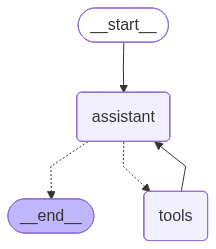

In [27]:
from langgraph.graph import START, StateGraph, END
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image


# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))


# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")


# Compile
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [28]:
import csv

# Open the CSV file
with open('quickbooks_emails_set_one.csv', 'r', newline='') as csvfile:
    # Create a csv.reader object
    csv_reader = csv.reader(csvfile)

    # Optionally, skip the header row if present
    header = next(csv_reader)
    print(f"Header: {header}")

    # Iterate over each row in the CSV file
    for row in csv_reader:
        print(row)
        try:
          messages = [HumanMessage(content=row[1])]
          messages = react_graph.invoke({"messages": messages})
          for m in messages['messages']:
              m.pretty_print()
        except Exception as e:
          print(e)
          print(row)
          print("Got an exception")

Header: ['Subject', 'Body']
['Credit card balance won’t reconcile', "Hey,\nNot sure what I’m doing wrong, but my credit card balance in QuickBooks doesn't match my bank statement—even though I double-checked and all the transactions seem to be there. Is there something else that could be throwing it off?\n\n—Marco"]
[values] {'messages': [HumanMessage(content="Hey,\nNot sure what I’m doing wrong, but my credit card balance in QuickBooks doesn't match my bank statement—even though I double-checked and all the transactions seem to be there. Is there something else that could be throwing it off?\n\n—Marco", additional_kwargs={}, response_metadata={}, id='2892c1e4-c9dd-4761-aa5e-411970db6671')]}
[updates] {'assistant': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 191, 'total_tokens': 226, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens

In [32]:
import pprint

print(f"Length of questions_seen_so_far: {len(questions_seen_so_far)} \n")
pprint.pp(questions_seen_so_far)


Length of questions_seen_so_far: 40 

{"Why doesn't my credit card balance in QuickBooks match my bank statement even though all transactions are there?": 1,
 'How do we enter upfront payments in QuickBooks without showing them as income?': 2,
 'How do we connect an upfront payment to an invoice in QuickBooks once the work is done?': 1,
 'How do we create a kit product in QuickBooks that deducts each part from inventory?': 2,
 'How can we determine how many kits we can make with the remaining inventory in QuickBooks?': 2,
 'How to handle business owner draws in QuickBooks?': 2,
 'Can business owner draws be automated in QuickBooks?': 2,
 'What data is transferred when moving from QuickBooks Desktop to QuickBooks Online?': 2,
 'Will payroll history transfer when moving from QuickBooks Desktop to QuickBooks Online?': 2,
 'Will inventory data transfer when moving from QuickBooks Desktop to QuickBooks Online?': 2,
 'Will vendor information transfer when moving from QuickBooks Desktop to Qu

Your prompt to the agent should look (something like) this on the first email:
```
Your role is to normalize the emails our customers are asking us. Use the normalize_question tool to extract a normalized form of the questions being asked in this email.
```

Your prompt should look something like this on the second email:
```
Your role is to normalize the emails our customers are asking us. Use the normalize_question tool to extract a normalized form of the questions being asked in this email.
Here are the questions you have seen so far:
- How do I pay myself in Quickbooks?
- How do I set up a recurring invoice in Quickbooks?
```

On the third:
```
Your role is to normalize the emails our customers are asking us. Use the normalize_question tool to extract a normalized form of the questions being asked in this email.
Here are the questions you have seen so far:
- How do I pay myself in Quickbooks?
- How do I set up a recurring invoice in Quickbooks?
- How do I clear an invoice I have written off in Quickbooks?
```